In [1]:
import control as ct
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [2]:
s = ct.TransferFunction.s
G = 1 / (s**2 + s + 1)

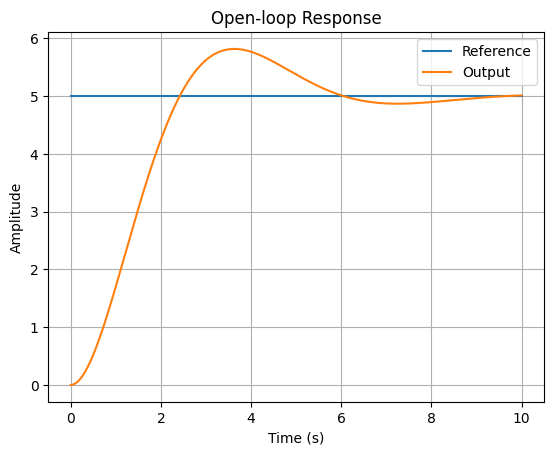

In [3]:
t = np.linspace(0, 10, 1000)
r = 5 * np.ones_like(t)
t, y = ct.forced_response(G, t, r)
plt.plot(t, r, label='Reference')
plt.plot(t, y, label='Output')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Open-loop Response')
plt.legend()
plt.grid()

In [4]:
def pid(Kp, Ki, Kd):
    return Kp + Ki/s + Kd*s

In [5]:
# Cost = tracking error
def cost(params):
    Kp, Ki, Kd = params
    C = pid(Kp, Ki, Kd)
    T = ct.feedback(C * G)

    t = np.linspace(0, 10, 1000)
    r = 5 * np.ones_like(t)
    t, y = ct.forced_response(T, t, r)

    error = r - y
    return np.sum(error**2) + 0.1 * (Kp**2 + Ki**2 + Kd**2)  # Add regularization to prevent excessively large gains

In [6]:
result = minimize(cost, [1, 1, 0.1], bounds=((0, None), (0, None), (0, None)))
print(result.x)

[ 7.805041    8.28360286 17.7030203 ]


93.50117807614136


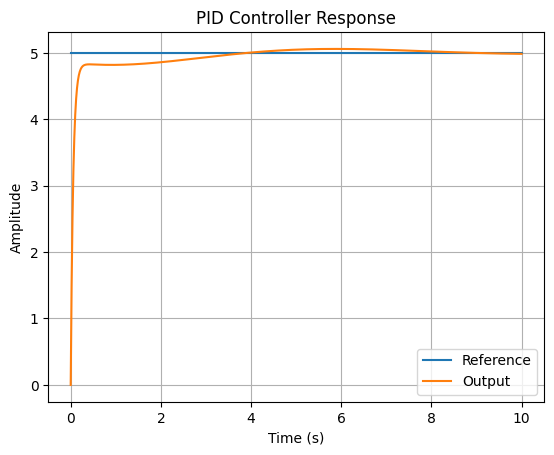

In [7]:
Kp, Ki, Kd = result.x
C = pid(Kp, Ki, Kd)
T = ct.feedback(C * G)
t = np.linspace(0, 10, 1000)
r = 5 * np.ones_like(t)
t, y = ct.forced_response(T, t, r)
plt.plot(t, r, label='Reference')
plt.plot(t, y, label='Output')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('PID Controller Response')
plt.legend()
plt.grid()

print(np.sum((r - y)**2))